In [13]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(
    "ignore",
    message="The default of observed=False is deprecated",
    category=FutureWarning
)

In [14]:
# Load h5ad file
adata = sc.read_h5ad("Hochane_PMID_30789893.h5ad")

In [15]:
print(adata.obs['cell_type'].unique())

['kidney cell', 'kidney epithelial cell', 'kidney interstitial cell', 'podocyte', 'endothelial cell', 'epithelial cell of proximal tubule', 'mesonephric nephron tubule epithelial cell', 'kidney connecting tubule epithelial cell', 'leukocyte', 'glomerular mesangial cell']
Categories (10, object): ['endothelial cell', 'podocyte', 'leukocyte', 'epithelial cell of proximal tubule', ..., 'kidney cell', 'kidney interstitial cell', 'glomerular mesangial cell', 'kidney connecting tubule epithelial cell']


In [16]:
cakut_genes = pd.read_csv("CAKUT_genes.csv", header=None)[1].tolist()
cakut_genes

['x',
 'ENSG00000005073',
 'ENSG00000008710',
 'ENSG00000011143',
 'ENSG00000046651',
 'ENSG00000046651.1',
 'ENSG00000048342',
 'ENSG00000054598',
 'ENSG00000066468',
 'ENSG00000068885',
 'ENSG00000075891',
 'ENSG00000077943',
 'ENSG00000078579',
 'ENSG00000080644',
 'ENSG00000099942',
 'ENSG00000100373',
 'ENSG00000102312',
 'ENSG00000103449',
 'ENSG00000103494',
 'ENSG00000104313',
 'ENSG00000107485',
 'ENSG00000112837',
 'ENSG00000113971',
 'ENSG00000114861',
 'ENSG00000118762',
 'ENSG00000118965',
 'ENSG00000119650',
 'ENSG00000121741',
 'ENSG00000122507',
 'ENSG00000125124',
 'ENSG00000126602',
 'ENSG00000126778',
 'ENSG00000129675',
 'ENSG00000133019',
 'ENSG00000133059',
 'ENSG00000135541',
 'ENSG00000135744',
 'ENSG00000138686',
 'ENSG00000138759',
 'ENSG00000140463',
 'ENSG00000141052',
 'ENSG00000141449',
 'ENSG00000143839',
 'ENSG00000144891',
 'ENSG00000145147',
 'ENSG00000148384',
 'ENSG00000150893',
 'ENSG00000151892',
 'ENSG00000155974',
 'ENSG00000157796',
 'ENSG000001

In [17]:
# Filter to genes present in your dataset
cakut_genes_in_data = [gene for gene in cakut_genes if gene in adata.var_names]
print(f"{len(cakut_genes_in_data)} CAKUT genes found in dataset.")

89 CAKUT genes found in dataset.


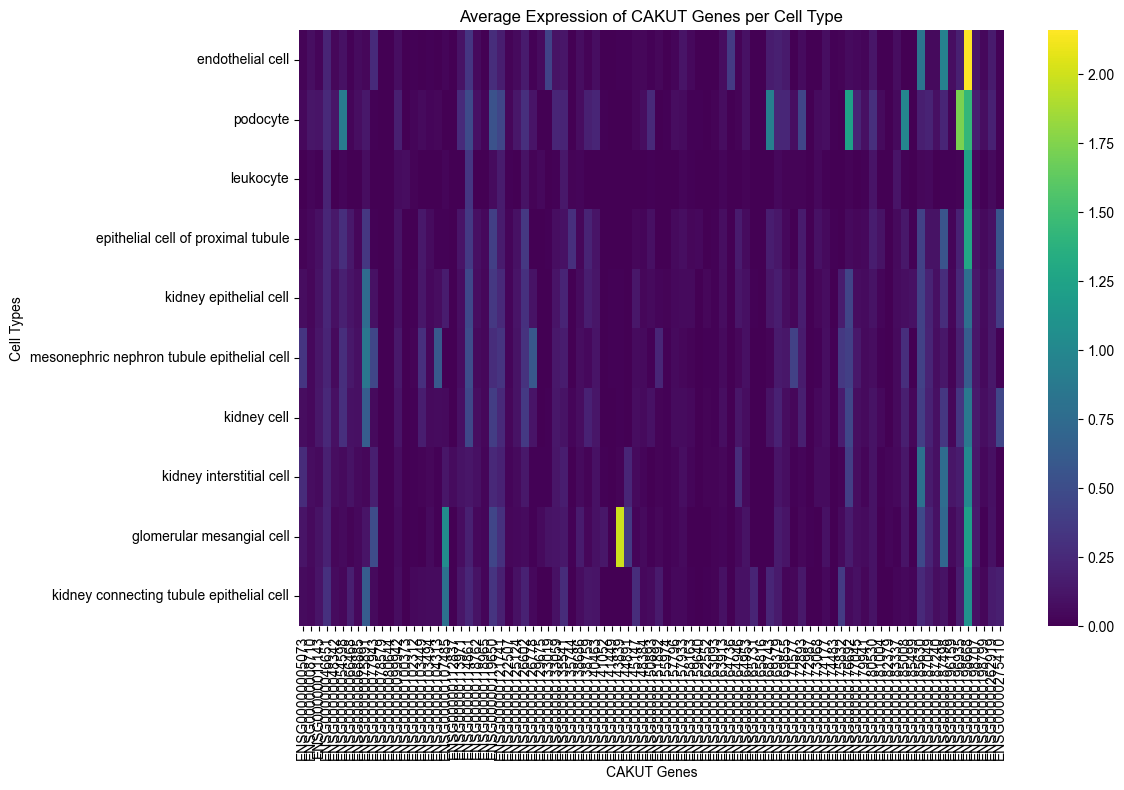

In [18]:
# Group by cell type and compute average expression of CAKUT genes
avg_expr = (
    adata.to_df()[cakut_genes_in_data]
    .groupby(adata.obs['cell_type'])
    .mean()
)

# Save or visualize
avg_expr.to_csv("CAKUT_expression_by_celltype.csv")
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(avg_expr, cmap="viridis", xticklabels=True, yticklabels=True)
plt.title("Average Expression of CAKUT Genes per Cell Type")
plt.xlabel("CAKUT Genes")
plt.ylabel("Cell Types")
plt.tight_layout()
plt.show()


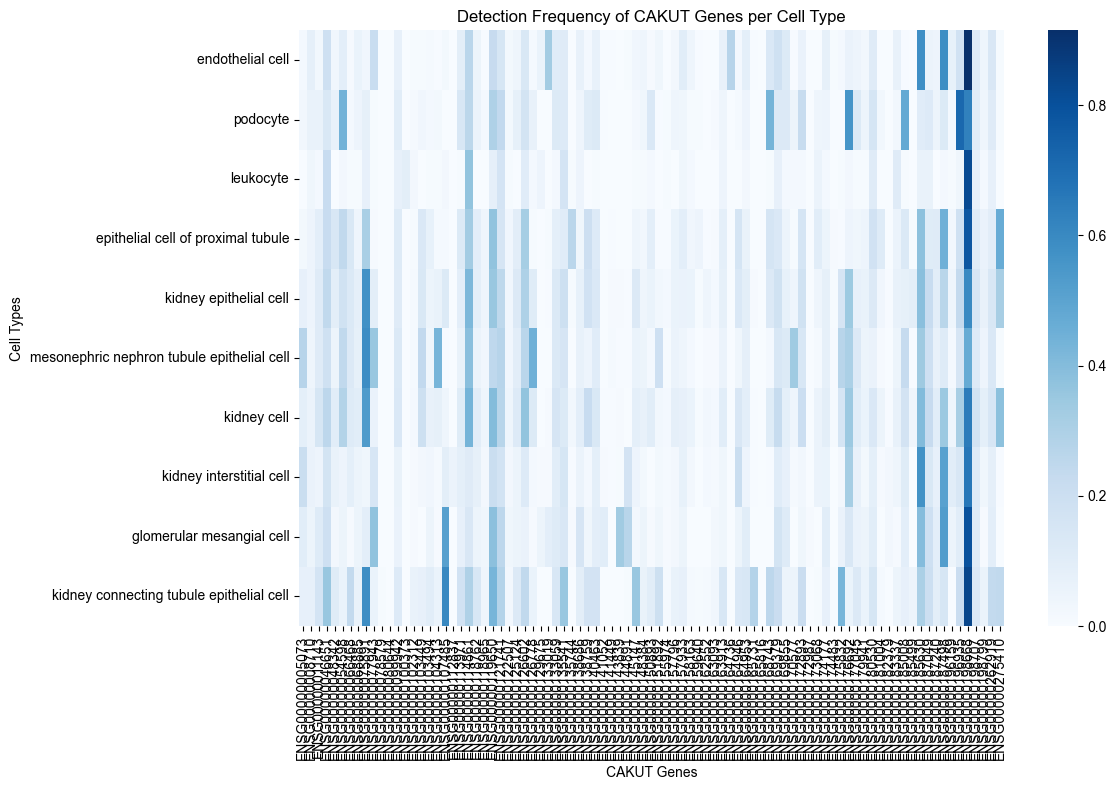

In [19]:
binary_expr = (adata.to_df()[cakut_genes_in_data] > 0).astype(int)
detection = binary_expr.groupby(adata.obs['cell_type']).mean()
detection.to_csv("CAKUT_detection_frequency.csv")

plt.figure(figsize=(12, 8))
sns.heatmap(detection, cmap="Blues", xticklabels=True, yticklabels=True)
plt.title("Detection Frequency of CAKUT Genes per Cell Type")
plt.xlabel("CAKUT Genes")
plt.ylabel("Cell Types")
plt.tight_layout()
plt.show()


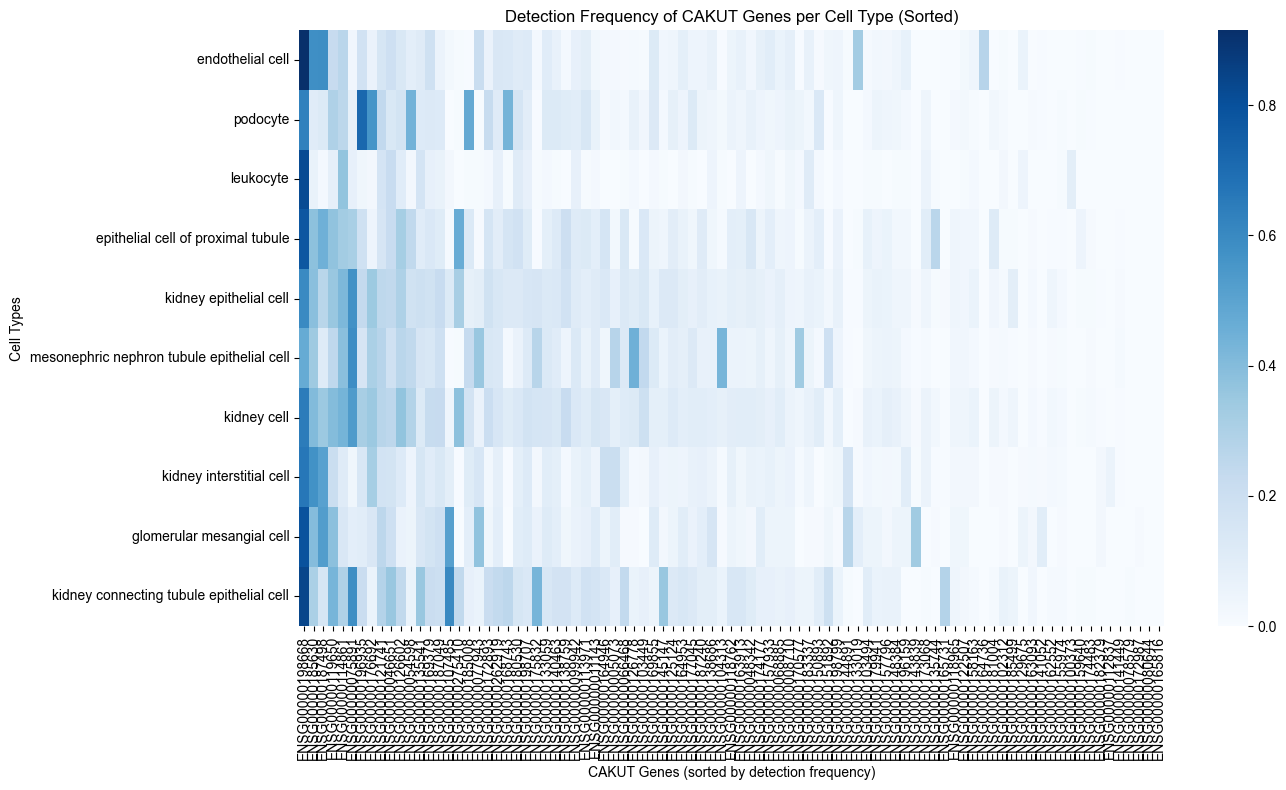

In [20]:
import numpy as np

# Calculate binary expression
binary_expr = (adata.to_df()[cakut_genes_in_data] > 0).astype(int)

# Calculate detection frequency per cell type
detection = binary_expr.groupby(adata.obs['cell_type']).mean()

# Sort genes by overall detection frequency (mean across all cell types)
mean_detection = detection.mean(axis=0)  # average across rows (cell types)
sorted_genes = mean_detection.sort_values(ascending=False).index.tolist()

# Reorder columns of detection matrix
detection_sorted = detection[sorted_genes]

# Plot
plt.figure(figsize=(14, 8))
sns.heatmap(detection_sorted, cmap="Blues", xticklabels=True, yticklabels=True)
plt.title("Detection Frequency of CAKUT Genes per Cell Type (Sorted)")
plt.xlabel("CAKUT Genes (sorted by detection frequency)")
plt.ylabel("Cell Types")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


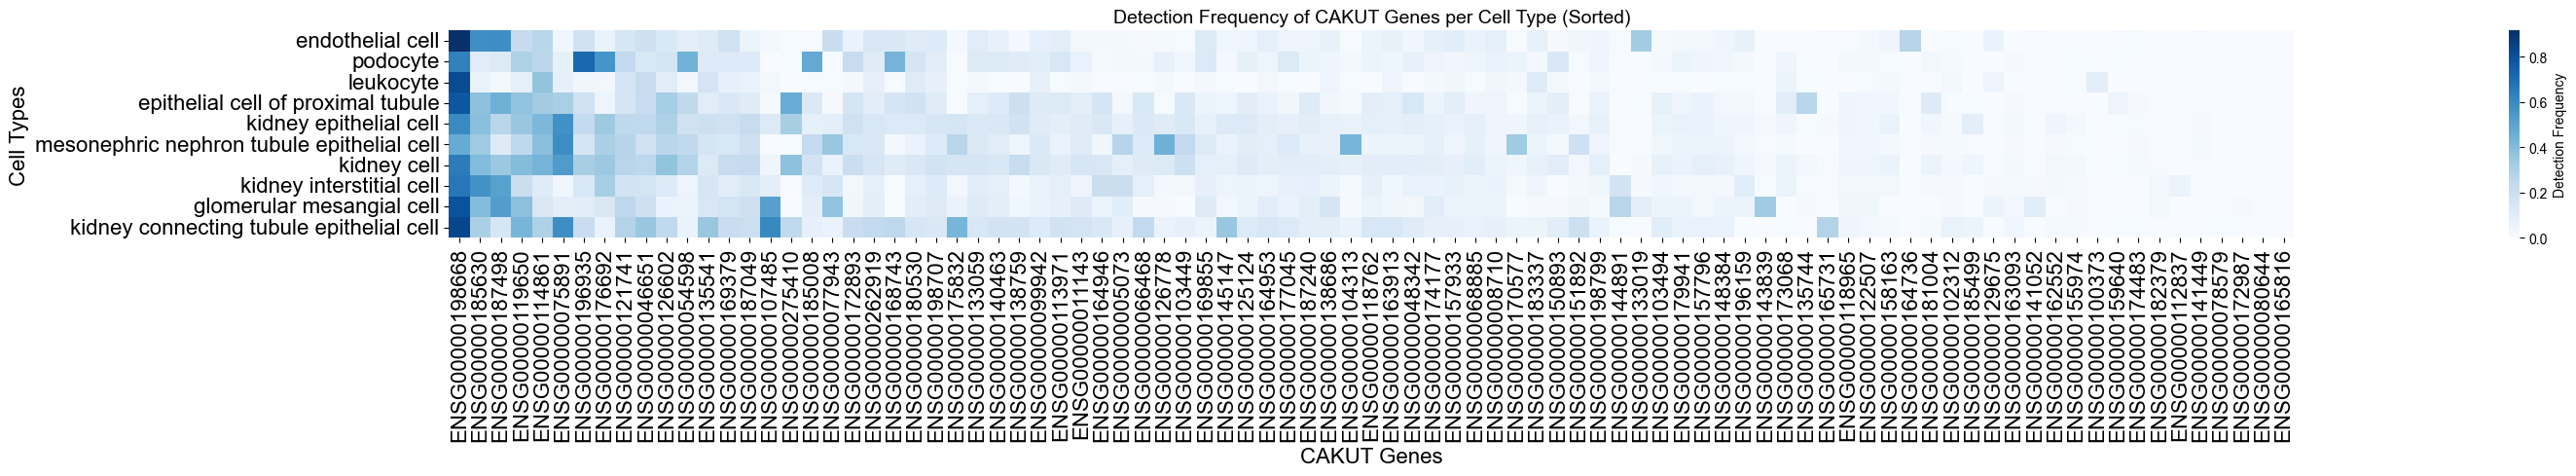

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate binary expression and detection as before
binary_expr = (adata.to_df()[cakut_genes_in_data] > 0).astype(int)
detection = binary_expr.groupby(adata.obs['cell_type']).mean()

# Sort genes by average detection frequency
mean_detection = detection.mean(axis=0)
sorted_genes = mean_detection.sort_values(ascending=False).index.tolist()
detection_sorted = detection[sorted_genes]

# Set figure size relative to matrix shape to keep cells approximately square
n_cell_types, n_genes = detection_sorted.shape
cell_size = 0.5  # adjust if needed
fig_width = n_genes * cell_size
fig_height = n_cell_types * cell_size

# Plot
plt.figure(figsize=(fig_width, fig_height))
sns.heatmap(
    detection_sorted,
    cmap="Blues",
    xticklabels=True,
    yticklabels=True,
    square=True,
    cbar_kws={"label": "Detection Frequency"}
)
plt.title("Detection Frequency of CAKUT Genes per Cell Type (Sorted)", fontsize=14)
plt.xlabel("CAKUT Genes", fontsize=16)
plt.ylabel("Cell Types", fontsize=16)
plt.xticks(rotation=90, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()


# Save to PDF before showing the plot
plt.tight_layout()
plt.savefig("CAKUT_AverageDetection_Heatmap.pdf", format="pdf")
plt.show()


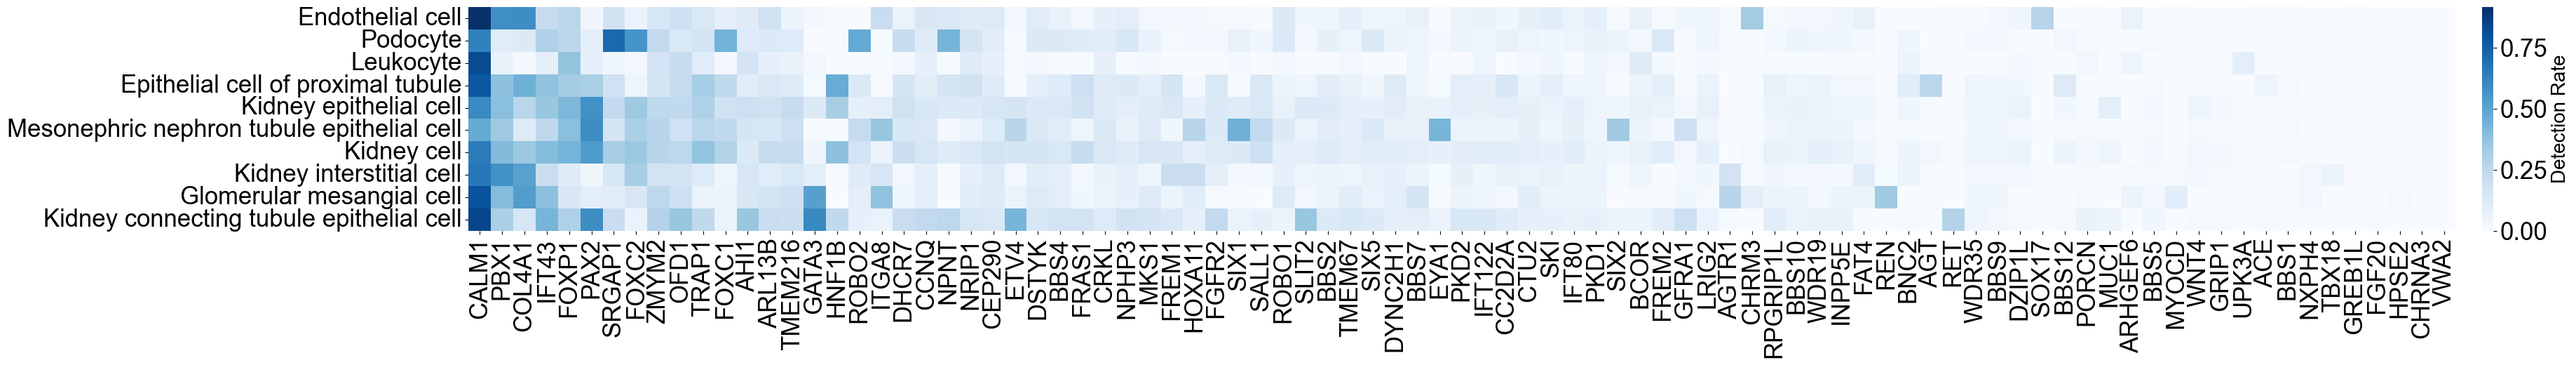

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'  # or 'Helvetica'


# Step 1: Calculate binary expression and group by cell type
binary_expr = (adata.to_df()[cakut_genes_in_data] > 0).astype(int)
detection = binary_expr.groupby(adata.obs['cell_type']).mean()

# Step 2: Sort genes by overall detection frequency
mean_detection = detection.mean(axis=0)
sorted_genes = mean_detection.sort_values(ascending=False).index.tolist()
detection_sorted = detection[sorted_genes]

# Step 3: Load Ensembl → Gene name conversion table
conversion = pd.read_csv("./Human_Embryos/CAKUT_genes.csv")  # replace with actual file path
ensembl_to_gene = dict(zip(conversion["EnsemblID"], conversion["Gene"]))

# Step 4: Replace Ensembl IDs with gene names
detection_sorted.columns = [ensembl_to_gene.get(g, g) for g in detection_sorted.columns]

# Step 5: Capitalize first letter of each cell type
detection_sorted.index = [s[0].upper() + s[1:] if len(s) > 0 else s for s in detection_sorted.index]

# Optional: save to CSV
detection_sorted.to_csv("CAKUT_detection_by_celltype_named.csv")

# Step 6: Plot heatmap
n_cell_types, n_genes = detection_sorted.shape
cell_size = 0.5
fig_width = n_genes * cell_size
fig_height = n_cell_types * cell_size

plt.figure(figsize=(fig_width, fig_height))
ax = sns.heatmap(
    detection_sorted,
    cmap="Blues",
    xticklabels=True,
    yticklabels=True,
    square=True,
    cbar_kws={"label": "Detection Rate", "shrink": 1, "pad": 0.01}  # closer and same size
)

# Remove title and axis labels
plt.title("")
plt.xlabel("")
plt.ylabel("")

# Adjust tick font sizes
plt.xticks(rotation=90, fontsize=25)
plt.yticks(fontsize=25)

# Increase colorbar font size
colorbar = ax.collections[0].colorbar
colorbar.ax.tick_params(labelsize=25)
colorbar.set_label("Detection Rate", fontsize=20)

plt.tight_layout()
plt.savefig("CAKUT_DetectionFrequency_Heatmap_Named.pdf", format="pdf")
plt.show()


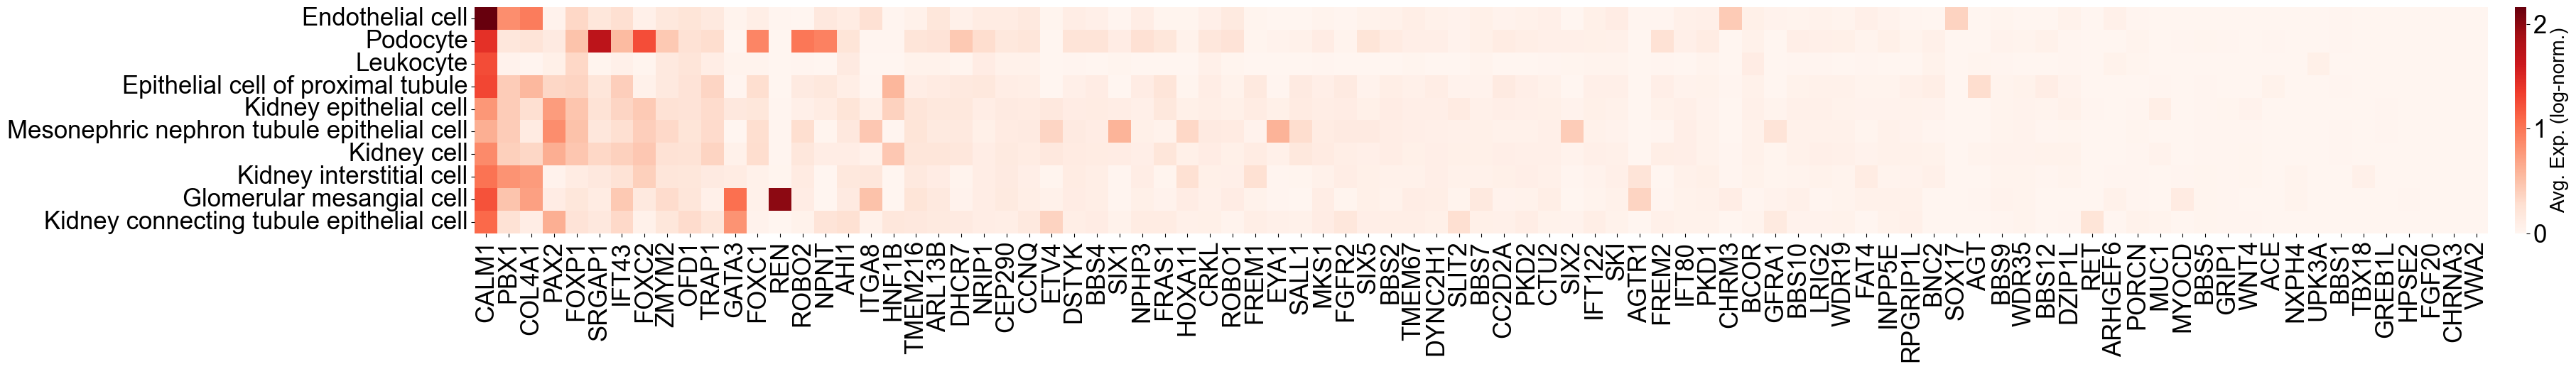

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'  # or 'Helvetica'

# Step 1: Compute average expression per cell type for CAKUT genes
avg_expr = (
    adata.to_df()[cakut_genes_in_data]
    .groupby(adata.obs['cell_type'])
    .mean()
)

# Step 2: Sort genes by average expression (descending)
avg_expr_sorted = avg_expr.loc[:, avg_expr.mean(axis=0).sort_values(ascending=False).index]

# Step 3: Load Ensembl → Gene name conversion table
conversion = pd.read_csv("./Human_Embryos/CAKUT_genes.csv")  # Replace with actual filename
ensembl_to_gene = dict(zip(conversion["EnsemblID"], conversion["Gene"]))

# Step 4: Rename columns to gene names
avg_expr_sorted.columns = [ensembl_to_gene.get(g, g) for g in avg_expr_sorted.columns]

# Step 5: Capitalize first letter of each cell type
avg_expr_sorted.index = [s[0].upper() + s[1:] if len(s) > 0 else s for s in avg_expr_sorted.index]

# Optional: save to CSV
avg_expr_sorted.to_csv("CAKUT_expression_by_celltype_named.csv")

# Step 6: Plot heatmap
cell_size = 0.5
fig_width = avg_expr_sorted.shape[1] * cell_size
fig_height = avg_expr_sorted.shape[0] * cell_size

plt.figure(figsize=(fig_width, fig_height))
ax = sns.heatmap(
    avg_expr_sorted,
    cmap="Reds",  # low = white, high = red
    xticklabels=True,
    yticklabels=True,
    square=True,
    cbar_kws={"label": "Average Expression (log-normalized)", "shrink": 1, "pad": 0.01}
)

# Remove axis titles and title
plt.title("")
plt.xlabel("")
plt.ylabel("")

# Adjust tick font sizes
plt.xticks(rotation=90, fontsize=25)
plt.yticks(fontsize=25)

# Adjust colorbar font
colorbar = ax.collections[0].colorbar
colorbar.ax.tick_params(labelsize=25)
colorbar.set_label("Avg. Exp. (log-norm.)", fontsize=20)

plt.tight_layout()
plt.savefig("CAKUT_AverageExpression_Heatmap_Named.pdf", format="pdf")
plt.show()


In [24]:
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.stats import kruskal
from statsmodels.stats.multitest import fdrcorrection

# Ensure CAKUT gene list is present and filtered
cakut_genes = pd.read_csv("CAKUT_genes.csv", header=None)[1].tolist()
genes_in_data = [gene for gene in cakut_genes if gene in adata.var_names]

# Extract cell type metadata
cell_types = adata.obs['cell_type'].astype(str)
adata_df = adata.to_df()[genes_in_data]
adata_df['cell_type'] = cell_types.values

# Perform Kruskal–Wallis test for each gene
pvals = []
gene_names = []

for gene in genes_in_data:
    try:
        groups = [group[gene].values for name, group in adata_df.groupby('cell_type')]
        stat, pval = kruskal(*groups)
        pvals.append(pval)
        gene_names.append(gene)
    except ValueError:
        # If not enough observations in a group
        pvals.append(np.nan)
        gene_names.append(gene)

# Multiple testing correction (Benjamini-Hochberg FDR)
rejected, pvals_corrected = fdrcorrection(pvals, alpha=0.05)

# Store results in a DataFrame
results_df = pd.DataFrame({
    'Gene': gene_names,
    'Raw_pval': pvals,
    'FDR': pvals_corrected,
    'Significant': rejected
}).sort_values('FDR')

# Save to CSV
results_df.to_csv("CAKUT_KruskalWallis_CellTypeSpecificity.csv", index=False)

# Print summary
print(f"Significant genes at FDR < 0.05: {results_df['Significant'].sum()} / {len(results_df)}")


Significant genes at FDR < 0.05: 87 / 89


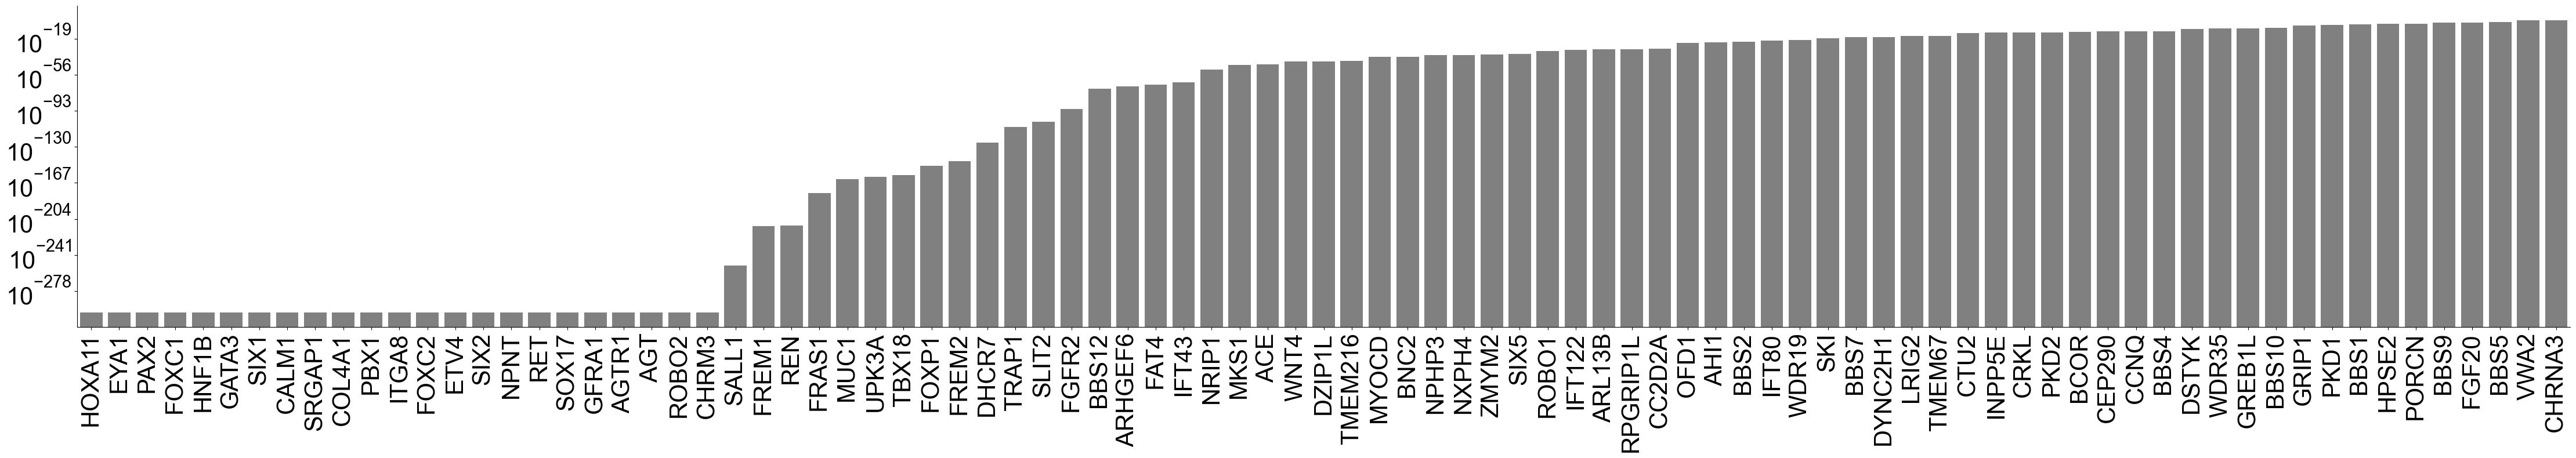

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib as mpl

# Use Arial or Helvetica for cleaner style
mpl.rcParams['font.family'] = 'Arial'

# Step 1: Load gene name conversion
conversion = pd.read_csv("./Human_Embryos/CAKUT_genes.csv")  # columns: EnsemblID, Gene
ensembl_to_gene = dict(zip(conversion["EnsemblID"], conversion["Gene"]))

# Step 2: Prepare data with minimum cutoff
min_pval = 1e-300
plot_df = results_df.copy()
plot_df['FDR'] = plot_df['FDR'].clip(lower=min_pval)
plot_df['Raw_pval'] = plot_df['Raw_pval'].clip(lower=min_pval)

# Step 3: Replace Ensembl IDs with gene names
plot_df['Gene_name'] = plot_df['Gene'].map(ensembl_to_gene).fillna(plot_df['Gene'])

# Step 4: Sort genes by FDR
plot_df = plot_df.sort_values('FDR')

# Step 5: Plot
plt.figure(figsize=(plot_df.shape[0] * 0.5, 8))
ax = sns.barplot(
    data=plot_df,
    x='Gene_name',
    y='FDR',
    color='gray'
)

# Remove box (top and right spines)
sns.despine(top=True, right=True, left=False, bottom=False)

# Set log scale for y-axis
plt.yscale('log')

# Clean style
plt.xticks(rotation=90, fontsize=30)
plt.yticks(fontsize=30)
plt.xlabel("")
plt.ylabel("")
plt.title("")
plt.legend([], [], frameon=False)

plt.tight_layout()
plt.savefig("CAKUT_KruskalWallis_FDR_clean.pdf", format="pdf")
plt.show()


In [26]:
import pandas as pd
import numpy as np

# =========================
# INPUTS
# =========================
# adata: AnnData object
# cakut_genes_in_data: list of CAKUT genes present in adata.var_names
# adata.obs must contain a column called 'cell_type'
# Optional conversion file with columns: EnsemblID, Gene

conversion_file = "./Human_Embryos/CAKUT_genes.csv"   # optional
celltype_col = "cell_type"
output_csv = "CAKUT_TableS2_avgexpr_detection_TSscore.csv"

# =========================
# CHECKS
# =========================
if celltype_col not in adata.obs.columns:
    raise ValueError(f"Column '{celltype_col}' not found in adata.obs")

if len(cakut_genes_in_data) == 0:
    raise ValueError("cakut_genes_in_data is empty")

missing_genes = [g for g in cakut_genes_in_data if g not in adata.var_names]
if len(missing_genes) > 0:
    print(f"Warning: {len(missing_genes)} genes were not found in adata.var_names and will be ignored.")

genes_present = [g for g in cakut_genes_in_data if g in adata.var_names]

# =========================
# LOAD EXPRESSION MATRIX
# =========================
expr_df = adata.to_df()[genes_present].copy()
expr_df[celltype_col] = adata.obs[celltype_col].values

# Optional: capitalize first letter of cell type labels
expr_df[celltype_col] = expr_df[celltype_col].astype(str).apply(
    lambda s: s[0].upper() + s[1:] if len(s) > 0 else s
)

# =========================
# 1) AVERAGE EXPRESSION
# =========================
avg_expr = expr_df.groupby(celltype_col)[genes_present].mean()

# =========================
# 2) DETECTION RATE
#    fraction of cells with expression > 0
# =========================
binary_expr = (expr_df[genes_present] > 0).astype(int)
binary_expr[celltype_col] = expr_df[celltype_col].values
detection = binary_expr.groupby(celltype_col)[genes_present].mean()

# =========================
# 3) TS SCORE
#    Here we define:
#    TS score = avg expression in a cell type / sum of avg expression across all cell types for that gene
#
#    Interpretation:
#    - close to 1  -> highly specific to that cell type
#    - low value   -> broadly expressed
# =========================
denominator = avg_expr.sum(axis=0)
denominator = denominator.replace(0, np.nan)  # avoid division by zero
ts_score = avg_expr.divide(denominator, axis=1).fillna(0)

# =========================
# OPTIONAL: TOP CELL TYPE PER GENE
# =========================
top_celltype_avgexpr = avg_expr.idxmax(axis=0).to_dict()
top_celltype_detection = detection.idxmax(axis=0).to_dict()
top_celltype_ts = ts_score.idxmax(axis=0).to_dict()

# =========================
# OPTIONAL: ENSEMBL -> GENE SYMBOL CONVERSION
# =========================
gene_name_map = {g: g for g in genes_present}

try:
    conversion = pd.read_csv(conversion_file)
    required_cols = {"EnsemblID", "Gene"}
    if required_cols.issubset(conversion.columns):
        gene_name_map.update(dict(zip(conversion["EnsemblID"], conversion["Gene"])))
    else:
        print(f"Warning: conversion file found, but it does not contain columns {required_cols}. Using original gene IDs.")
except FileNotFoundError:
    print("Conversion file not found. Using original gene IDs.")
except Exception as e:
    print(f"Could not load conversion file: {e}. Using original gene IDs.")

# =========================
# CONVERT TO LONG FORMAT
# =========================
avg_long = avg_expr.reset_index().melt(
    id_vars=celltype_col, var_name="Gene_ID", value_name="Average_Expression"
)

det_long = detection.reset_index().melt(
    id_vars=celltype_col, var_name="Gene_ID", value_name="Detection_Rate"
)

ts_long = ts_score.reset_index().melt(
    id_vars=celltype_col, var_name="Gene_ID", value_name="TS_Score"
)

# Merge all metrics
table_s2 = avg_long.merge(det_long, on=[celltype_col, "Gene_ID"]).merge(ts_long, on=[celltype_col, "Gene_ID"])

# Add gene symbols
table_s2["Gene"] = table_s2["Gene_ID"].map(gene_name_map).fillna(table_s2["Gene_ID"])

# Add top cell-type annotations per gene
table_s2["Top_CellType_by_AvgExpr"] = table_s2["Gene_ID"].map(top_celltype_avgexpr)
table_s2["Top_CellType_by_Detection"] = table_s2["Gene_ID"].map(top_celltype_detection)
table_s2["Top_CellType_by_TS"] = table_s2["Gene_ID"].map(top_celltype_ts)

# Reorder columns
table_s2 = table_s2[
    [
        "Gene",
        "Gene_ID",
        celltype_col,
        "Average_Expression",
        "Detection_Rate",
        "TS_Score",
        "Top_CellType_by_AvgExpr",
        "Top_CellType_by_Detection",
        "Top_CellType_by_TS",
    ]
]

# =========================
# SORT TABLE
# =========================
# Sort genes by overall mean expression, then by cell type
gene_order = avg_expr.mean(axis=0).sort_values(ascending=False).index.tolist()
table_s2["Gene_ID"] = pd.Categorical(table_s2["Gene_ID"], categories=gene_order, ordered=True)
table_s2 = table_s2.sort_values(["Gene_ID", celltype_col]).reset_index(drop=True)

# =========================
# SAVE
# =========================
table_s2.to_csv(output_csv, index=False)

print(f"Saved: {output_csv}")
print(table_s2.head(20))

Saved: CAKUT_TableS2_avgexpr_detection_TSscore.csv
     Gene          Gene_ID                                   cell_type  \
0   CALM1  ENSG00000198668                            Endothelial cell   
1   CALM1  ENSG00000198668          Epithelial cell of proximal tubule   
2   CALM1  ENSG00000198668                   Glomerular mesangial cell   
3   CALM1  ENSG00000198668                                 Kidney cell   
4   CALM1  ENSG00000198668    Kidney connecting tubule epithelial cell   
5   CALM1  ENSG00000198668                      Kidney epithelial cell   
6   CALM1  ENSG00000198668                    Kidney interstitial cell   
7   CALM1  ENSG00000198668                                   Leukocyte   
8   CALM1  ENSG00000198668  Mesonephric nephron tubule epithelial cell   
9   CALM1  ENSG00000198668                                    Podocyte   
10   PBX1  ENSG00000185630                            Endothelial cell   
11   PBX1  ENSG00000185630          Epithelial cell of proxim

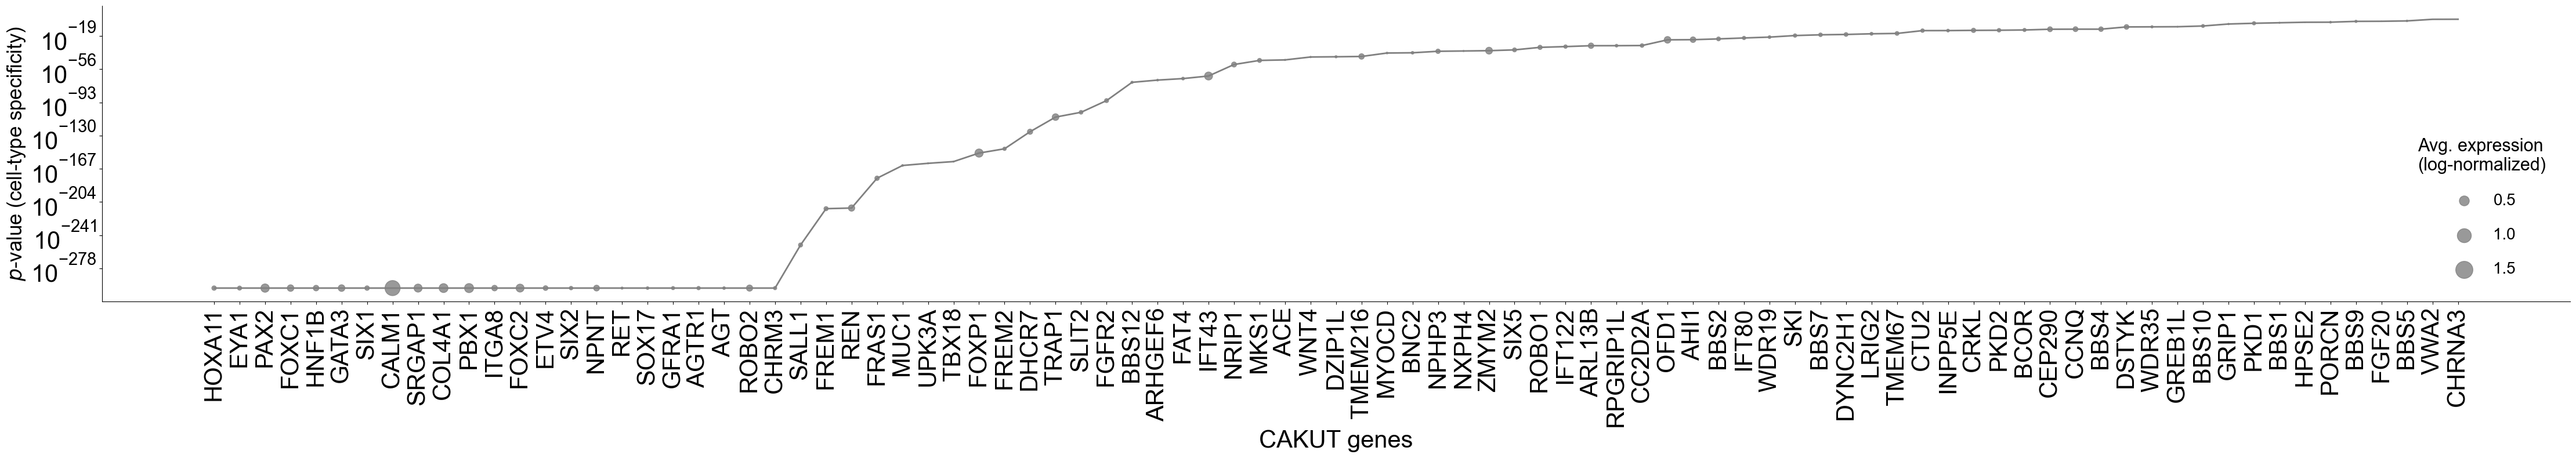

               Gene Gene_name       FDR
58  ENSG00000165816      VWA2  0.388855
11  ENSG00000080644    CHRNA3  0.460335
               Gene Gene_name       Raw_pval            FDR
0   ENSG00000005073    HOXA11   0.000000e+00   0.000000e+00
17  ENSG00000104313      EYA1   0.000000e+00   0.000000e+00
8   ENSG00000075891      PAX2   0.000000e+00   0.000000e+00
5   ENSG00000054598     FOXC1   0.000000e+00   0.000000e+00
88  ENSG00000275410     HNF1B   0.000000e+00   0.000000e+00
18  ENSG00000107485     GATA3   0.000000e+00   0.000000e+00
29  ENSG00000126778      SIX1   0.000000e+00   0.000000e+00
84  ENSG00000198668     CALM1   0.000000e+00   0.000000e+00
83  ENSG00000196935    SRGAP1   0.000000e+00   0.000000e+00
81  ENSG00000187498    COL4A1   0.000000e+00   0.000000e+00
78  ENSG00000185630      PBX1   0.000000e+00   0.000000e+00
9   ENSG00000077943     ITGA8   0.000000e+00   0.000000e+00
69  ENSG00000176692     FOXC2   0.000000e+00   0.000000e+00
68  ENSG00000175832      ETV4   0.000000

/var/folders/xm/vt_mg3wj0kl3801y787cntqr0000gn/T/ipykernel_6150/2339326650.py:91: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_significant['Gene_name'] = non_significant['Gene'].map(ensembl_to_gene).fillna(non_significant['Gene'])


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib as mpl
import matplotlib.lines as mlines

# Set font
mpl.rcParams['font.family'] = 'Arial'

# Load gene name conversion
conversion = pd.read_csv("./Human_Embryos/CAKUT_genes.csv")  # columns: EnsemblID, Gene
ensembl_to_gene = dict(zip(conversion["EnsemblID"], conversion["Gene"]))

# Prepare FDR data
min_pval = 1e-300
plot_df = results_df.copy()
plot_df['FDR'] = plot_df['FDR'].clip(lower=min_pval)
plot_df['Raw_pval'] = plot_df['Raw_pval'].clip(lower=min_pval)
plot_df['Gene_name'] = plot_df['Gene'].map(ensembl_to_gene).fillna(plot_df['Gene'])

# Sort by FDR
plot_df = plot_df.sort_values('FDR')

# Compute average expression per gene (log-normalized)
avg_expr_per_gene = avg_expr_sorted.mean(axis=0)
plot_df['AvgExpr'] = plot_df['Gene_name'].map(avg_expr_per_gene).fillna(0)

# Set circle size proportional to expression (increase multiplier to enhance visibility)
dot_scale = 300  # adjust for visibility
plot_df['DotSize'] = plot_df['AvgExpr'] * dot_scale

# Plot
plt.figure(figsize=(plot_df.shape[0] * 0.5, 8))

# Line plot of FDR
plt.plot(plot_df['Gene_name'], plot_df['FDR'], color='gray', linewidth=2, zorder=1)

# Scatter overlay: size = average log-normalized expression
plt.scatter(
    x=plot_df['Gene_name'],
    y=plot_df['FDR'],
    s=plot_df['DotSize'],
    color='gray',
    alpha=0.8,
    zorder=2
)

# Axis formatting
plt.yscale('log')
plt.xticks(rotation=90, fontsize=30)
plt.yticks(fontsize=30)
plt.xlabel("CAKUT genes", fontsize=30)
plt.ylabel(r"$\it{p}$-value (cell-type specificity)", fontsize=25)
plt.title("")
sns.despine()

# Add legend for dot size (based on actual expression)
legend_expr_values = [0.5, 1.0, 1.5]
legend_sizes = [val * dot_scale for val in legend_expr_values]

handles = [
    plt.scatter([], [], s=size, color='gray', alpha=0.8, label=f"{val:.1f}")
    for size, val in zip(legend_sizes, legend_expr_values)
]

plt.legend(
    handles=handles,
    title="Avg. expression\n(log-normalized)",
    loc='lower right',
    labelspacing=1.2,
    borderpad=1,
    frameon=False,
    fontsize=20,
    title_fontsize=22
)

# Save and show
plt.tight_layout()
plt.savefig("CAKUT_KruskalWallis_FDR_LineDotPlot_LogExprLegend.pdf", format="pdf")
plt.show()


# Threshold for significance
fdr_threshold = 0.05

# Filter non-significant genes
non_significant = results_df[results_df['FDR'] >= fdr_threshold]

# Map to gene names
non_significant['Gene_name'] = non_significant['Gene'].map(ensembl_to_gene).fillna(non_significant['Gene'])

# View or print
non_significant_genes = non_significant[['Gene', 'Gene_name', 'FDR']].sort_values('FDR')
print(non_significant_genes)


# Map Ensembl IDs to gene names
results_df['Gene_name'] = results_df['Gene'].map(ensembl_to_gene).fillna(results_df['Gene'])

# Select and sort relevant columns
all_pvals = results_df[['Gene', 'Gene_name', 'Raw_pval', 'FDR']].sort_values('FDR')

# Print all rows
with pd.option_context('display.max_rows', None):
    print(all_pvals)


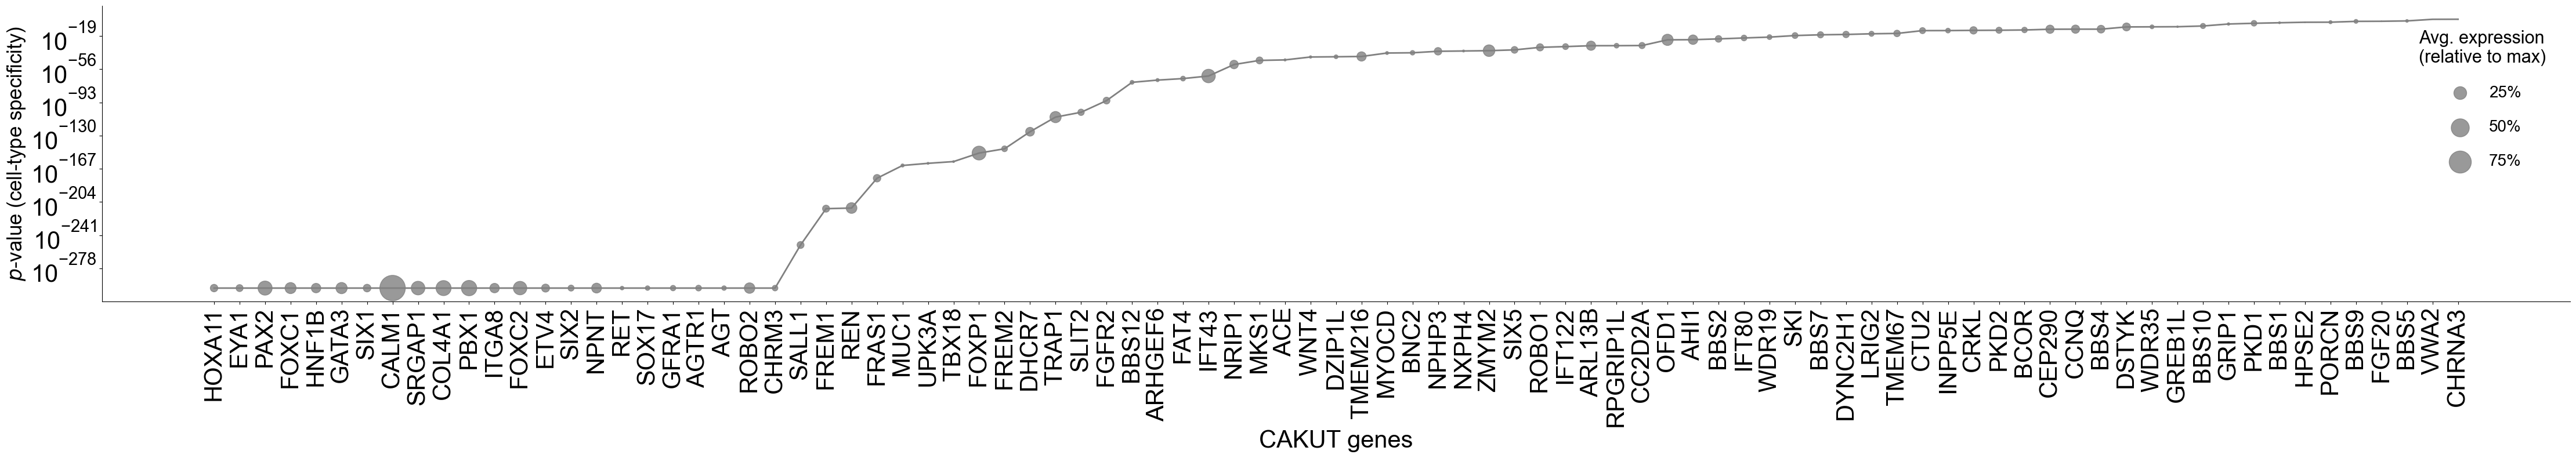

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib as mpl
import matplotlib.lines as mlines

# Set font
mpl.rcParams['font.family'] = 'Arial'

# Load gene name conversion
conversion = pd.read_csv("./Human_Embryos/CAKUT_genes.csv")  # columns: EnsemblID, Gene
ensembl_to_gene = dict(zip(conversion["EnsemblID"], conversion["Gene"]))

# Prepare FDR data
min_pval = 1e-300
plot_df = results_df.copy()
plot_df['FDR'] = plot_df['FDR'].clip(lower=min_pval)
plot_df['Raw_pval'] = plot_df['Raw_pval'].clip(lower=min_pval)
plot_df['Gene_name'] = plot_df['Gene'].map(ensembl_to_gene).fillna(plot_df['Gene'])

# Sort by FDR
plot_df = plot_df.sort_values('FDR')

# Compute average expression per gene
avg_expr_per_gene = avg_expr_sorted.mean(axis=0)
plot_df['AvgExpr'] = plot_df['Gene_name'].map(avg_expr_per_gene).fillna(0)

# Normalize expression for dot size
plot_df['DotSize'] = plot_df['AvgExpr'] / plot_df['AvgExpr'].max() * 1000  # adjust scaling

# Plot
plt.figure(figsize=(plot_df.shape[0] * 0.5, 8))

# Line plot of FDR
plt.plot(plot_df['Gene_name'], plot_df['FDR'], color='gray', linewidth=2, zorder=1)

# Scatter overlay with dot size ~ expression
plt.scatter(
    x=plot_df['Gene_name'],
    y=plot_df['FDR'],
    s=plot_df['DotSize'],
    color='gray',
    alpha=0.8,
    zorder=2
)

# Axis formatting
plt.yscale('log')
plt.xticks(rotation=90, fontsize=30)
plt.yticks(fontsize=30)
plt.xlabel("CAKUT genes", fontsize=30)
plt.ylabel(r"$\it{p}$-value (cell-type specificity)", fontsize=25)
plt.title("")
sns.despine()

# Add legend for dot size
legend_sizes = [0.25, 0.5, 0.75]
max_size = 1000
example_sizes = [s * max_size for s in legend_sizes]

handles = [
    plt.scatter([], [], s=size, color='gray', alpha=0.8, label=f"{int(fraction*100)}%")
    for size, fraction in zip(example_sizes, legend_sizes)
]

plt.legend(
    handles=handles,
    title="Avg. expression\n(relative to max)",
    loc='upper right',
    labelspacing=1.2,
    borderpad=1,
    frameon=False,
    fontsize=20,
    title_fontsize=22
)

# Save and show
plt.tight_layout()
plt.savefig("CAKUT_KruskalWallis_FDR_LineDotPlot_WithLegend.pdf", format="pdf")
plt.show()
